## PCA ANALYSIS FOR PEX-A HOTSPOT

In [1]:
from re import search, compile
from spectrum_preprocessing import pipeline, distribution_Selection, roundWavenumbers
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.optimize import curve_fit
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import pickle as pk
import numpy as np
import os

numlike = compile(r"^-?\d+(\.\d+)?$")

Functions

In [2]:
def IR_PCA(input_data, PCs, normalize):

    scaler = StandardScaler()
    if normalize == True:
        input_data = scaler.fit_transform(input_data)
    else:
        pass
    
    pca = PCA(n_components = PCs)
    data_PCs = pca.fit_transform(input_data)
    columns_list = ['PC'+ str(x) for x in range(1, PCs+1)]
    PC_df = pd.DataFrame(data = data_PCs,
                                columns = columns_list)
    
    feature_weights = pca.components_
    loadings_df = pd.DataFrame(feature_weights)
    
    print('Explained variation per principal component: {}'.format(pca.explained_variance_ratio_))
    
    return(PC_df, loadings_df)

Import and Format Data

In [10]:
if not os.path.exists("C:/Users/Zach/Documents/GitHub/Feature Extraction/KMeans_Feature_Extraction/training_data.csv"):
        filepath = 'C:/Users/Zach/Documents/GitHub/betaVAE_Training/training_data/'

        #file2 = 'SMP65 010 0-100d Hotspot Spectra 800um.csv'
        allFiles = os.listdir(filepath)
        # Take only the files that contain data pertaining to SMP65#010 
        trainingFiles = [file for file in allFiles if file.endswith('.csv') and 'SMP65#010' in file and 'full width' not in file and 'hotspot' not in file]

        trainingFiles = sorted(trainingFiles, key=lambda x: int(search(r'(?<= )(.+?)(?=d)', x).group()))

        print(trainingFiles)
        # Read all of the data and place the dataframes into a list
        trainingDataframeList = [pd.read_csv(filepath+file, low_memory=True, skiprows=[1,2]) for file in trainingFiles]

        masked_trainingDataframeList = []

        for df in trainingDataframeList:
                _, _, mask_selected, modePosition, areaPE = distribution_Selection(df, '1981.7 - 2095.8', 3)
                df[mask_selected] = df[mask_selected].ffill()
                masked_trainingDataframeList.append(df[mask_selected])
        trainingDataframeList = None # Clear memory

        rawTrainingDataframe = pd.concat(
        (
            df.rename(
                columns=lambda c: round(float(c), 1) if numlike.match(str(c).strip()) else c
            )
            for df in masked_trainingDataframeList
        ),
        ignore_index=True
        )

        training_df = pd.concat(masked_trainingDataframeList, ignore_index=True)
        training_df = roundWavenumbers(training_df)
        masked_trainingDataframeList = None # Clear memory of list of dataframes since we have one dataframe now

        numlike = compile(r"^-?\d+(\.\d+)?$")

        wavenumbers = np.array([c for c in training_df.columns if numlike.match(str(c).strip())])

        interpDataFramelist = []
        for index, full_row in training_df.iterrows():

                spectra = full_row[wavenumbers]
                metas = full_row.drop(wavenumbers)
                meta_cols = metas.index
                meta_values = metas.to_numpy()

                frequencies = spectra.index.to_numpy(dtype=float)
                frequencies = frequencies[::-1]  # Reverse the order for interpolation

                spectrum = spectra.to_numpy(dtype=float)
                spectrum = spectrum[::-1]  # Reverse the order for interpolation

                frequencies, spectrum = pipeline(frequencies, spectrum)

                cols = np.concatenate([meta_cols, frequencies])
                data = np.concatenate([meta_values, spectrum])

                interpDataFramelist.append(pd.DataFrame(data=[data], columns=cols))

        training_df = pd.concat(interpDataFramelist, ignore_index=True)
        
        wavenumbers = np.array([c for c in training_df.columns if numlike.match(str(c).strip())])

        frequencies = [float(wavenumber) for wavenumber in wavenumbers]

        training_df.to_csv("training_data.csv", index=False)

        grouped = training_df.groupby('Sample Name')

        keys = list(grouped.groups.keys())
        
        keys = sorted(keys, key=lambda s: int(search(r'(\d+)d', s).group(1)))

        print(keys)

        dfs = {key: grouped.get_group(key) for key in keys}

else:
        print("Training CSV File already exists.")
        filepath = "C:/Users/Zach/Documents/GitHub/Feature Extraction/KMeans_Feature_Extraction/training_data.csv"
        training_df = pd.read_csv(filepath, low_memory=True)

        numlike = compile(r"^-?\d+(\.\d+)?$")

        wavenumbers = np.array([c for c in training_df.columns if numlike.match(str(c).strip())])

        grouped = training_df.groupby('Sample Name')
        keys = list(grouped.groups.keys())
        
        keys = sorted(keys, key=lambda s: int(search(r'(\d+)d', s).group(1)))

        print(keys)

        dfs = {key: grouped.get_group(key) for key in keys}

legend_labels = training_df['Sample Name'].unique()
data_handles = []

Training CSV File already exists.
['0d 560um', '2d 800um', '4d 820um', '7d 830um', '14d 830um', '21d 820um', '28d 830um', '35d 850um', '42d 810um', '49d 830um', '56d 820um', '63d 830um', '70d 820um', '77d 810um', '84d 820um', '100d 820um']


Individual Sample PCA

Explained variation per principal component: [0.29776839 0.15356028 0.13142279 0.08348042 0.042826   0.0320888
 0.02921577 0.02624947 0.01823606 0.01520045]
Explained variation per principal component: [0.28360318 0.19617213 0.10560951 0.08588425 0.07730952 0.03484841
 0.02963859 0.01925876 0.01584944 0.01497052]
Explained variation per principal component: [0.30339402 0.16866437 0.11851911 0.08882878 0.07361338 0.03711692
 0.0241311  0.01891235 0.01717878 0.01356516]
Explained variation per principal component: [0.29785817 0.16037586 0.10668984 0.08349238 0.07709974 0.03816888
 0.03304252 0.02304204 0.01739632 0.01355869]
Explained variation per principal component: [0.31175452 0.26449266 0.11317809 0.06216948 0.05081105 0.03078133
 0.02241125 0.0160358  0.01170951 0.01065908]
Explained variation per principal component: [0.33021852 0.17826075 0.12925031 0.06757338 0.04202612 0.03948954
 0.02621322 0.02008442 0.01420772 0.01237532]
Explained variation per principal component: [0.42812

MovieWriter ffmpeg unavailable; using Pillow instead.


Explained variation per principal component: [0.46746958 0.12710663 0.07630653 0.05532737 0.04771144 0.03303353
 0.02063278 0.01760478 0.0130208  0.01165869]


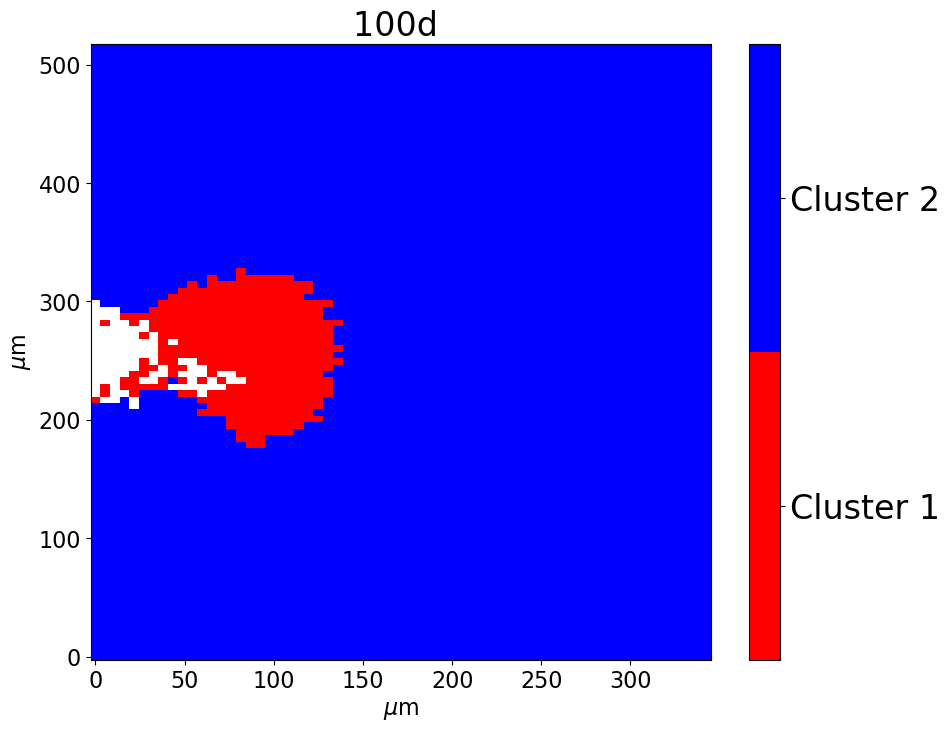

In [ ]:
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation
from sklearn.cluster import KMeans
os.environ["OMP_NUM_THREADS"] = "2" # Defining number of threads to avoid memory leak in Kmeans on Windows
from sklearn.metrics import silhouette_score

def animate(i, x_vals, y_vals):
    plt.cla()
    plt.plot(x_vals, y_vals)

list_of_labels = {}
Z_list = []*len(keys)

for i, key in enumerate(keys):
    training_df = dfs[key]
    #Reposition the mapping to start at 0,0 
    Map_x = training_df['map_x'].to_numpy()
    Map_y = training_df['map_y'].to_numpy()
    Map_y2 = []
    Map_x2 = []
    Min_x = min(Map_x)
    Min_y = min(Map_y)

    Map_x2 = Map_x - Min_x
    Map_y2 = Map_y - Min_y

    training_df.loc[:, 'map_x'] = Map_x2
    training_df.loc[:, 'map_y'] = Map_y2

    x_unique = np.sort(training_df["map_x"].unique())
    y_unique = np.sort(training_df["map_y"].unique())

    X, Y = np.meshgrid(x_unique, y_unique)

    PCs=10

    PC_inputData = training_df[wavenumbers].copy()

    PCA_output = IR_PCA(PC_inputData, PCs, normalize=True)

    PC_df = PCA_output[0]
    loadings_df = PCA_output[1]

    kmeans = KMeans(n_clusters=2, random_state=42).fit(PC_df.values)
    labels = kmeans.fit_predict(PC_df)
    # Arange the clusters by the consumption level, or the amount of data points the cluster contains
    cluster_sizes = np.bincount(labels)
    idx = np.argsort(cluster_sizes)
    lut = np.zeros_like(idx)
    lut[idx] = np.arange(2)

    training_df = training_df.copy()
    training_df["cluster"] = lut[labels]
    dfs[key] = training_df

    Z_list.append(training_df.pivot(index="map_y", columns="map_x", values="cluster").sort_index(ascending=True).values)
    
cmap = mcolors.ListedColormap(['red', 'blue'])

fig, ax = plt.subplots(figsize=(10, 8))

# Initial frame
mesh = ax.pcolormesh(
    X,
    Y,
    Z_list[0],
    shading="auto",
    cmap=cmap
)

# ONE colorbar only
cbar = plt.colorbar(mesh, ax=ax)

cbar.set_ticks([0.25, 0.75])
cbar.set_ticklabels(['Cluster 1', 'Cluster 2'], fontsize=24)

ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

ax.set_xlabel(f'$\mu$m', fontsize=16)
ax.set_ylabel(f'$\mu$m', fontsize=16)


# Optional titles for each frame
titles = [f"{key[:-5]}" for key in keys]

def animate(frame):

    # Update mesh values
    mesh.set_array(Z_list[frame].ravel())

    # Update title
    ax.set_title(titles[frame], fontsize=24)

    return mesh,

ani = FuncAnimation(
    fig,
    animate,
    frames=len(Z_list),
    interval=800,   
    blit=False,
    repeat=False
)
ani.save("./clusters_hyperspectra.gif", writer='pillow')
plt.show()

Plot Average Spectra of Clusters

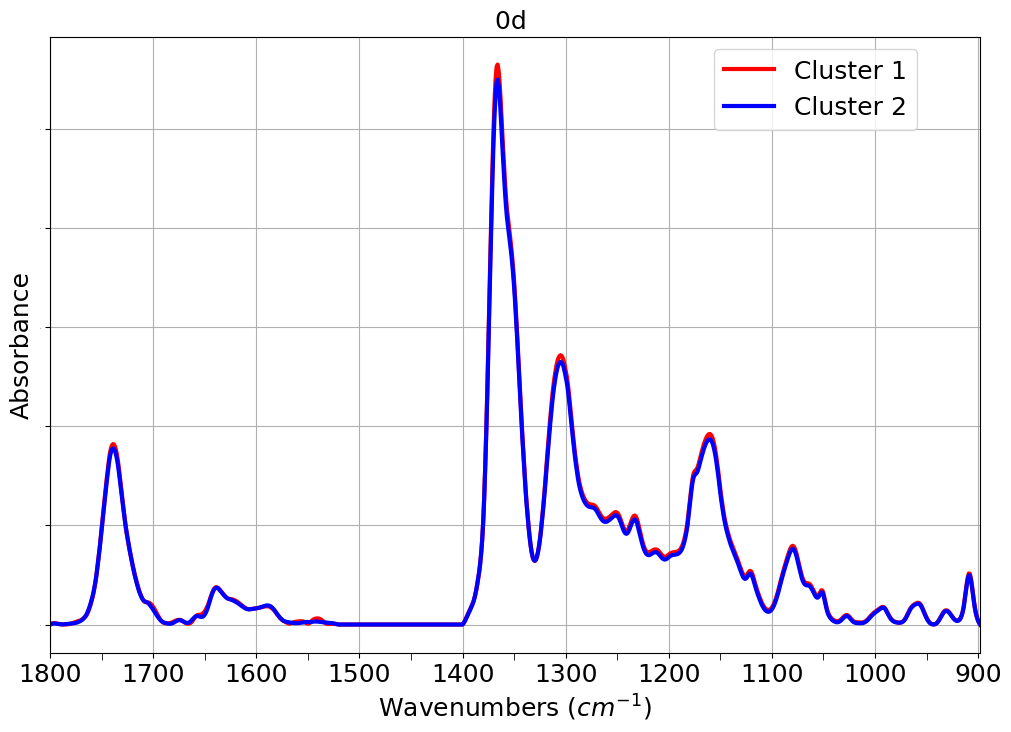

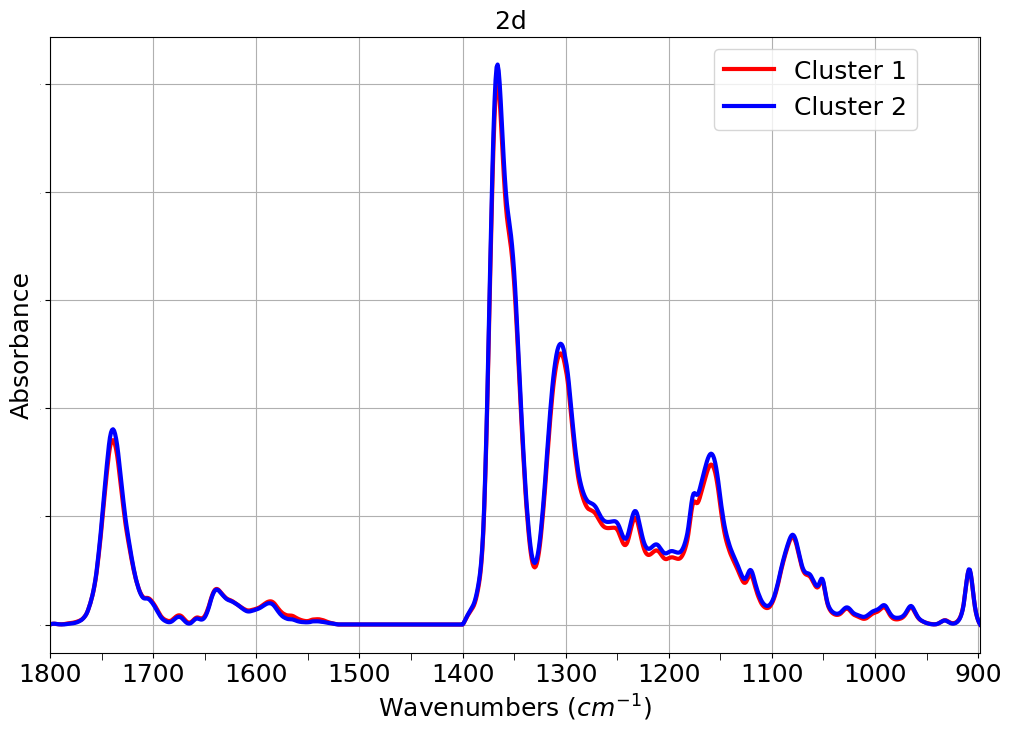

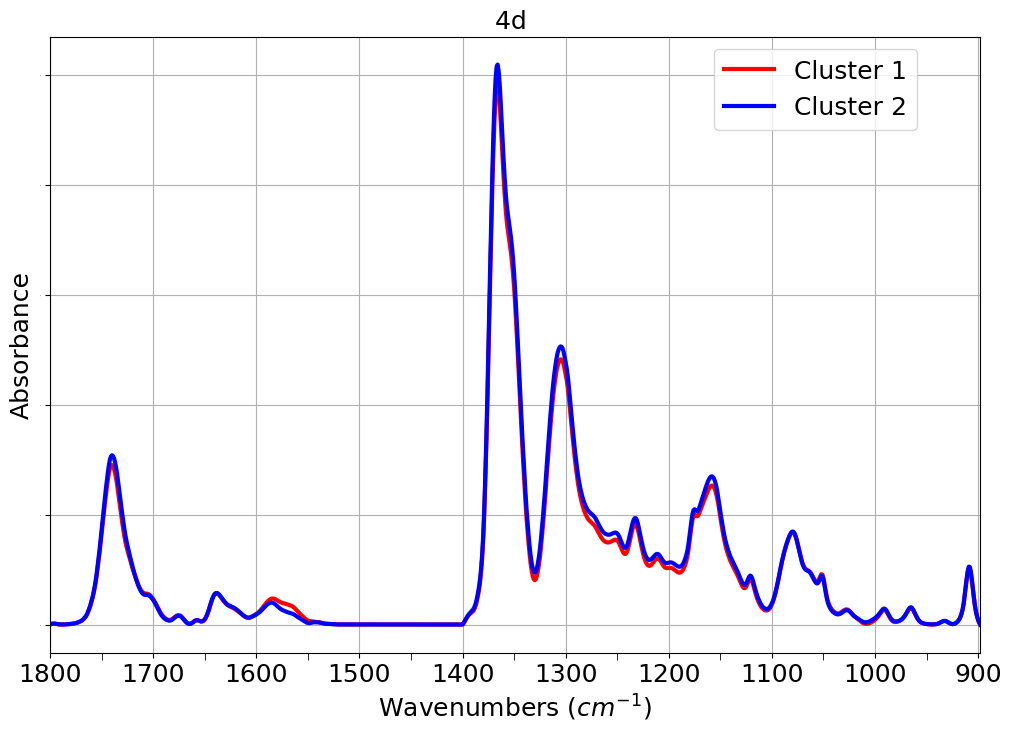

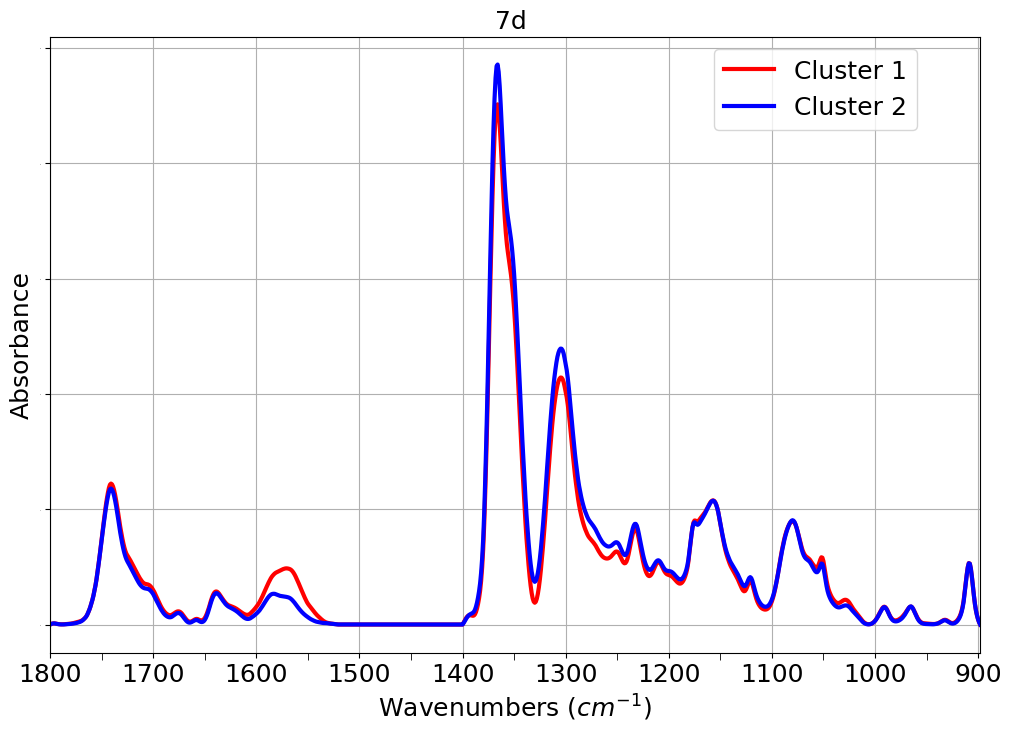

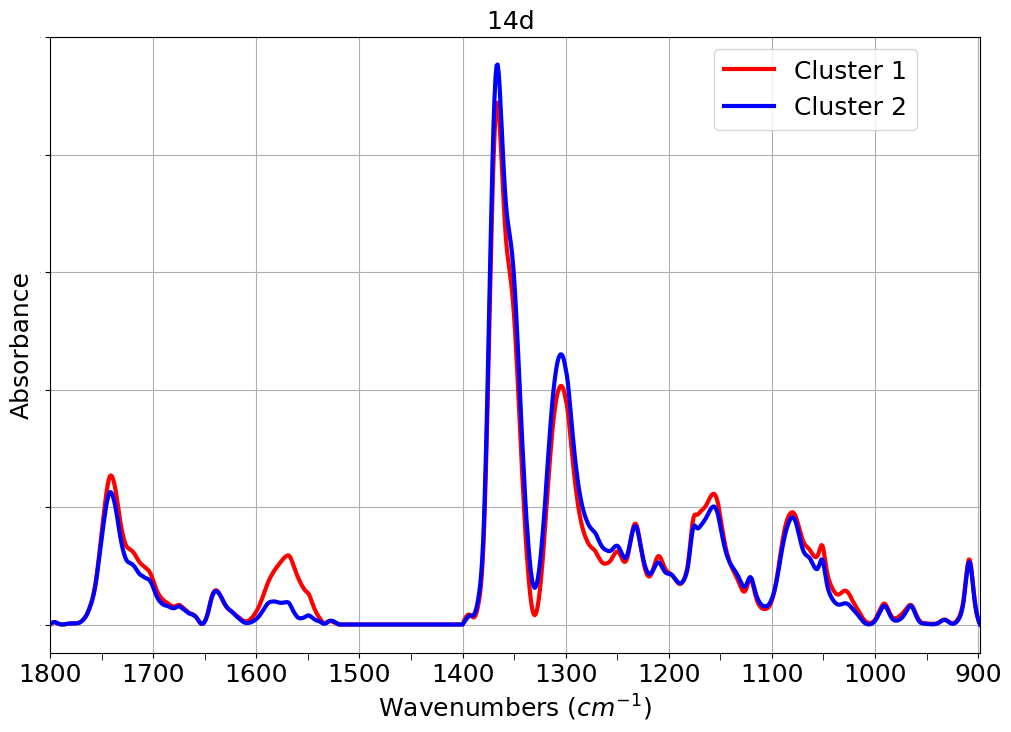

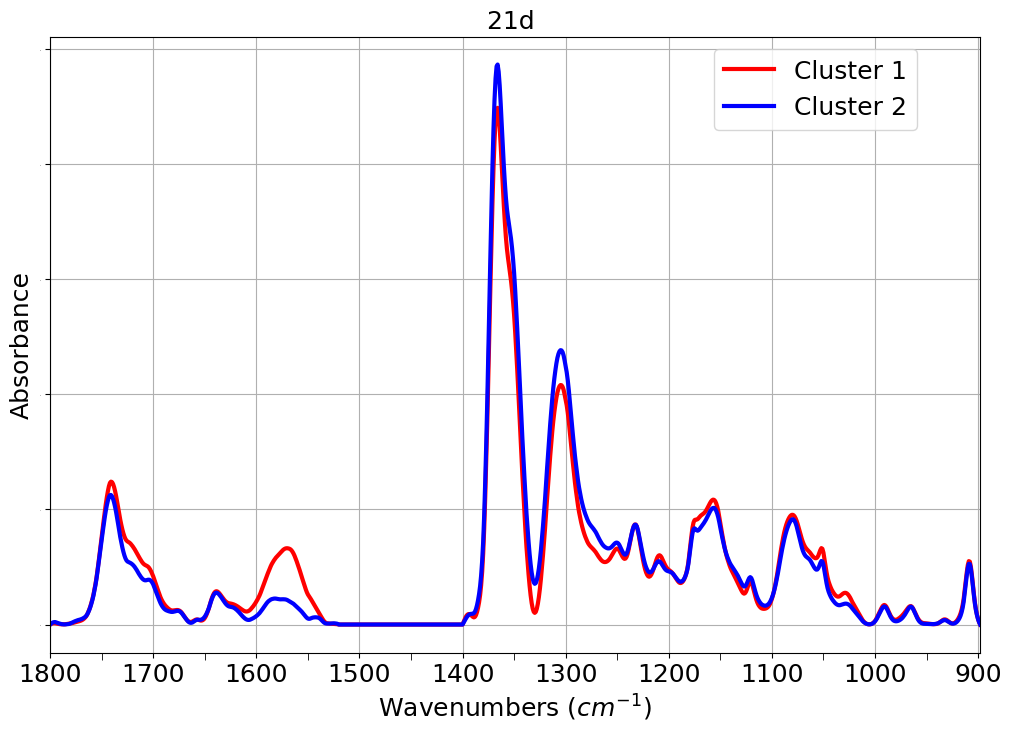

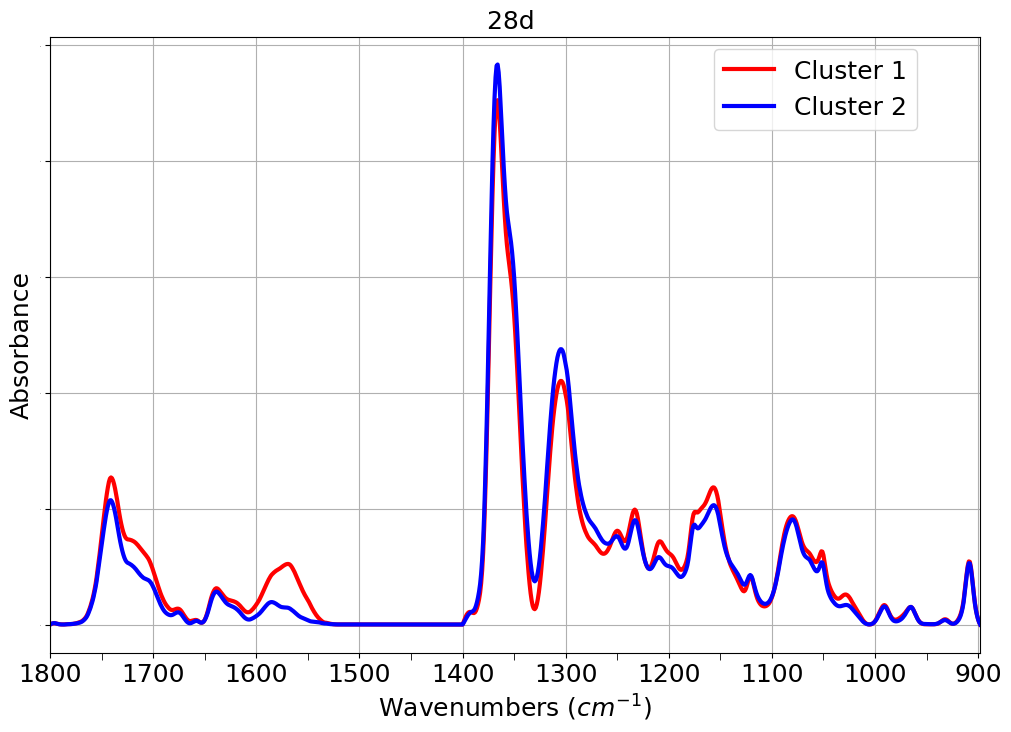

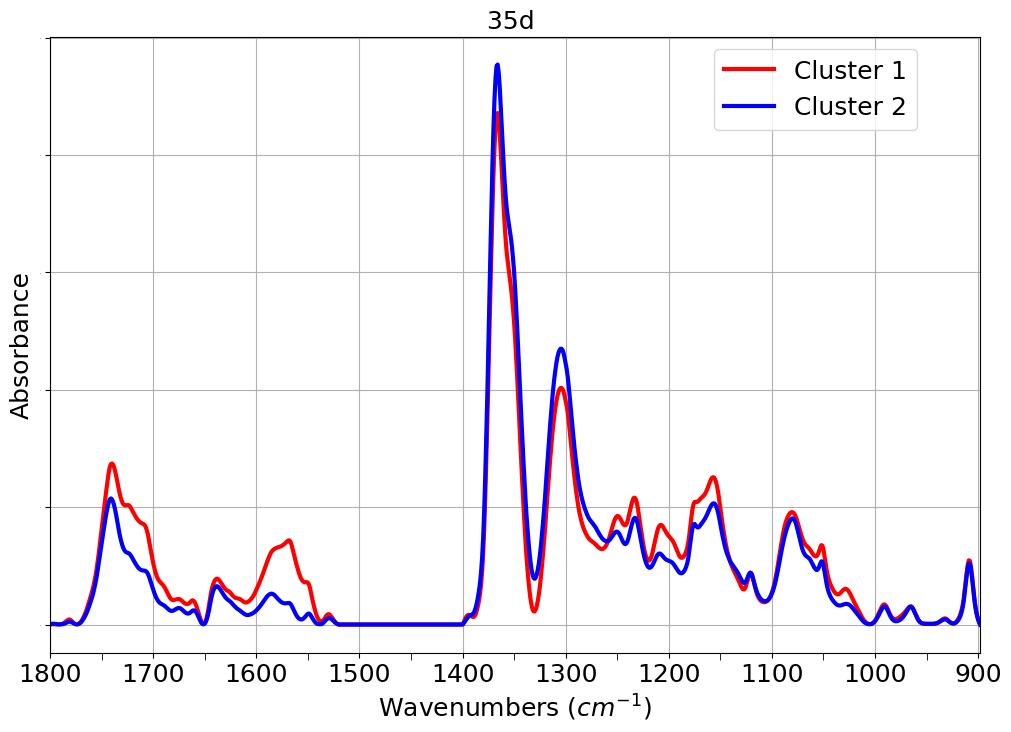

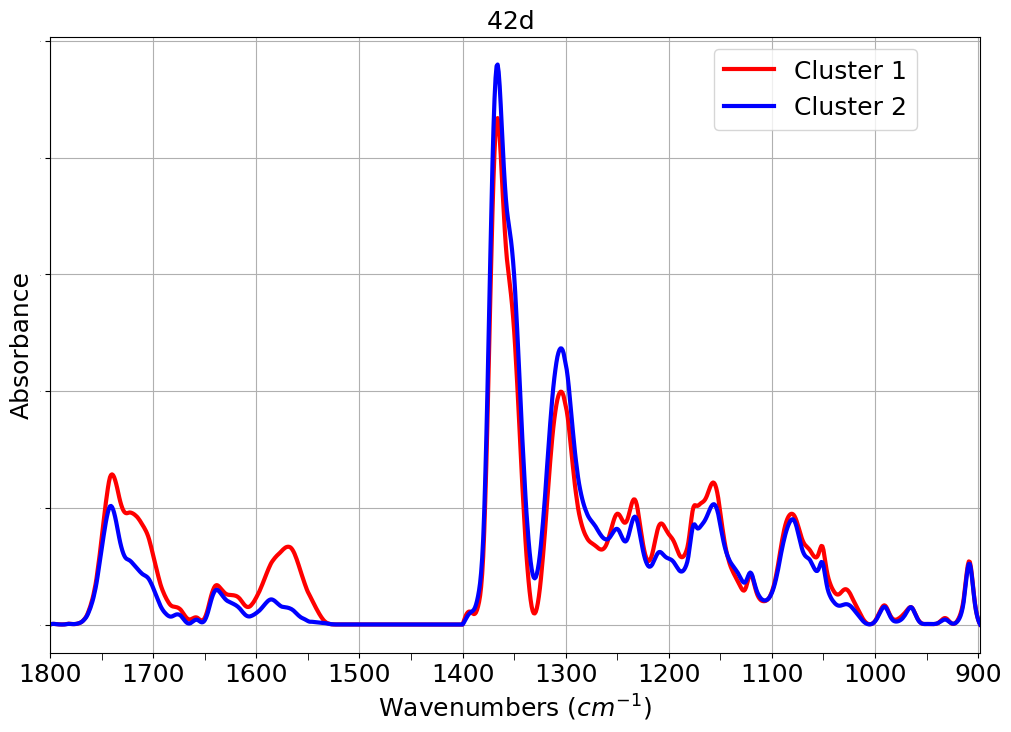

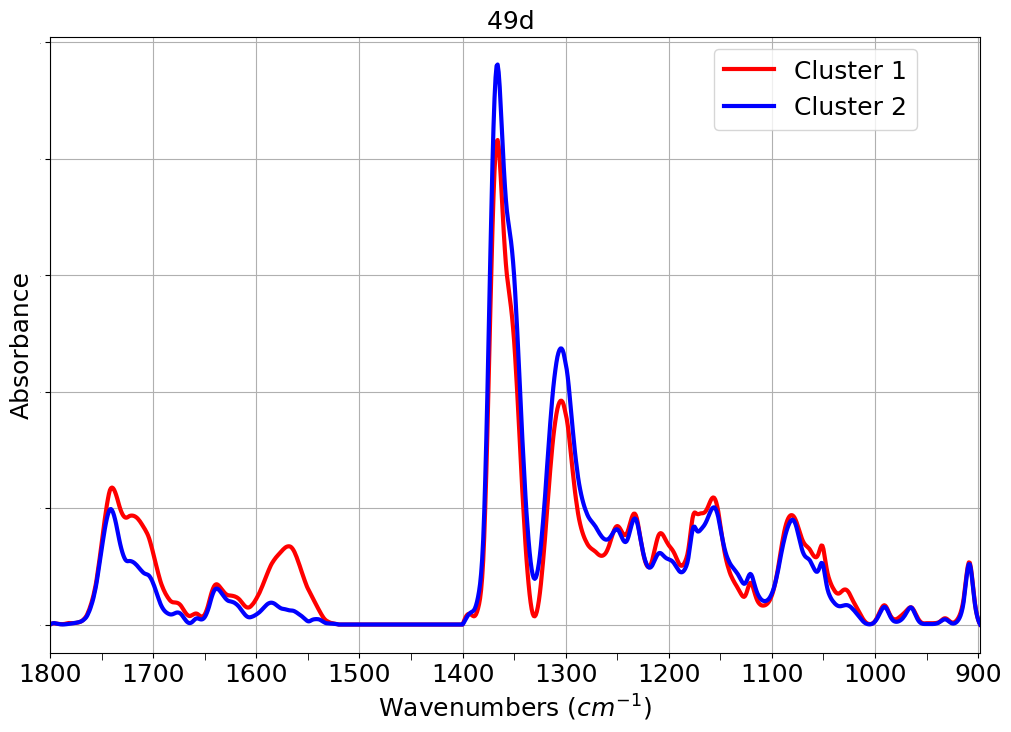

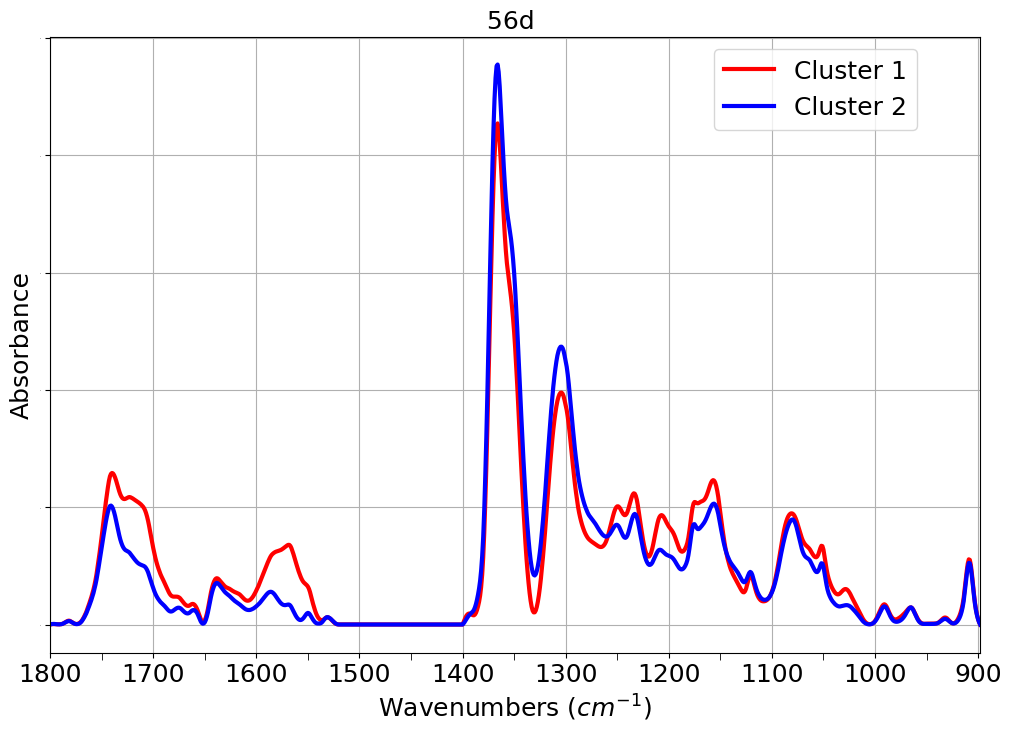

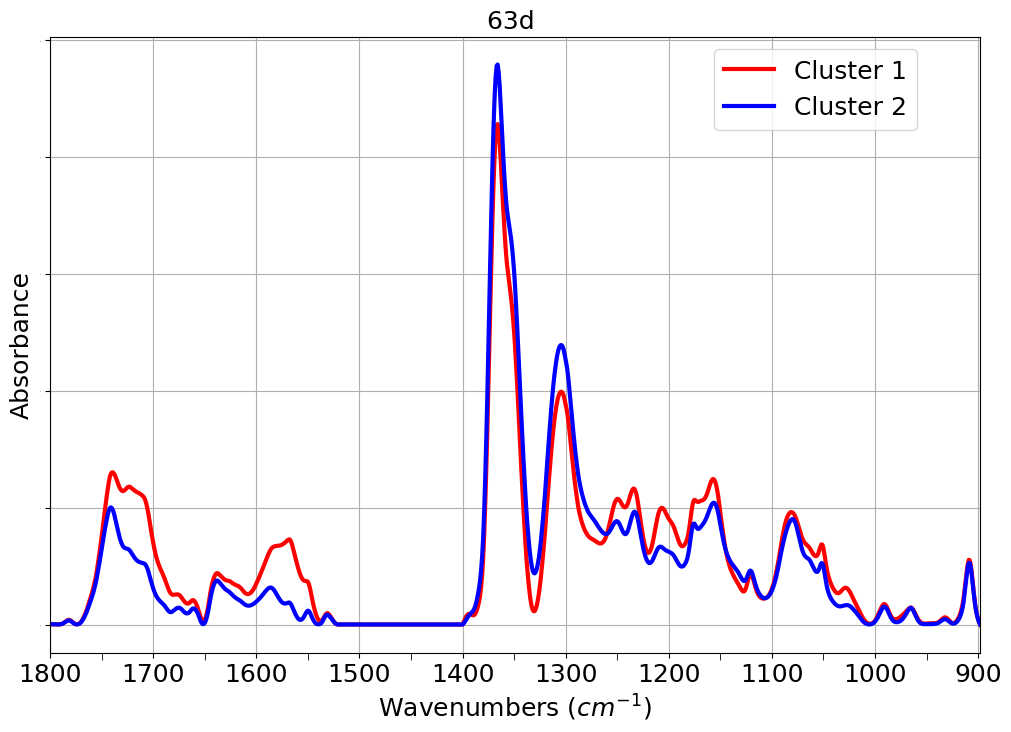

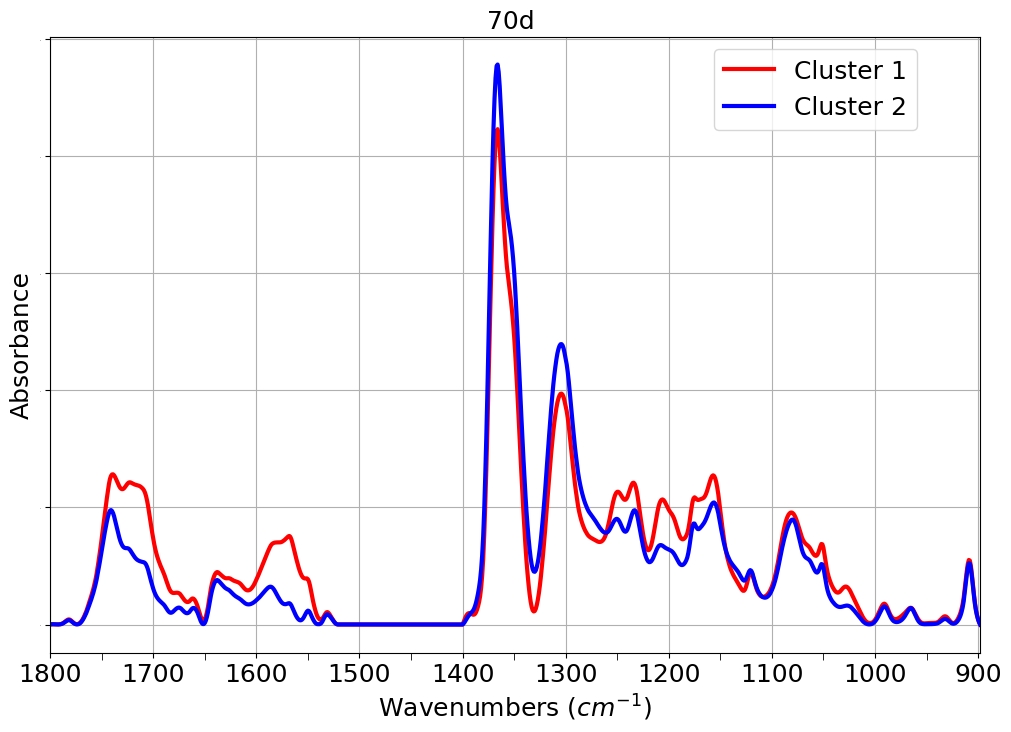

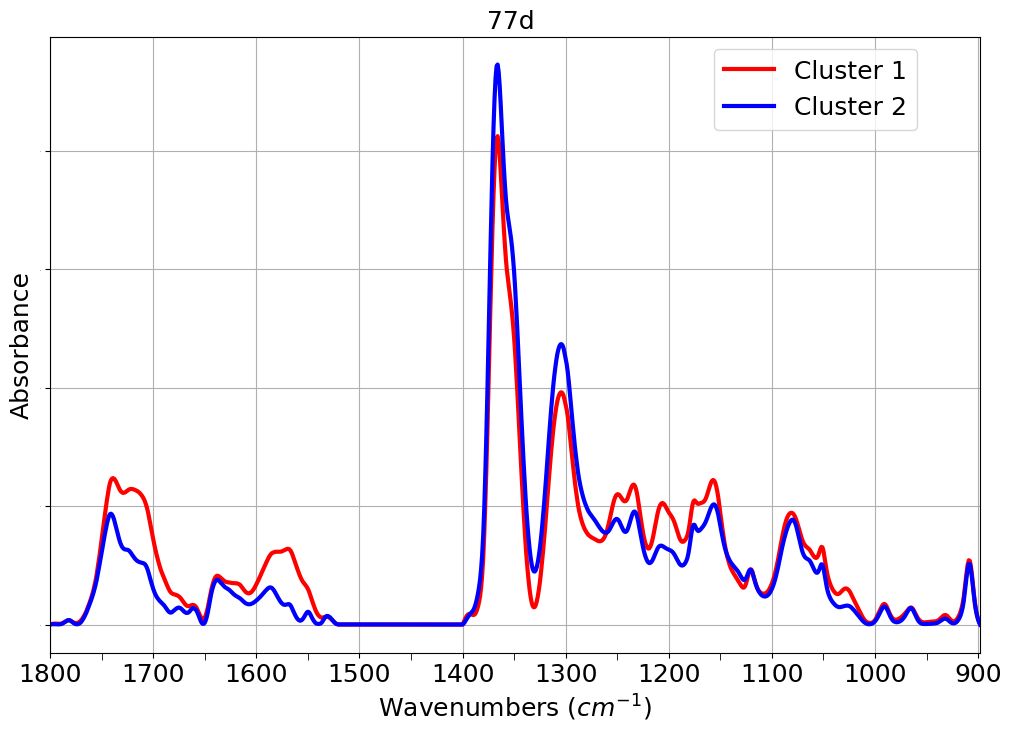

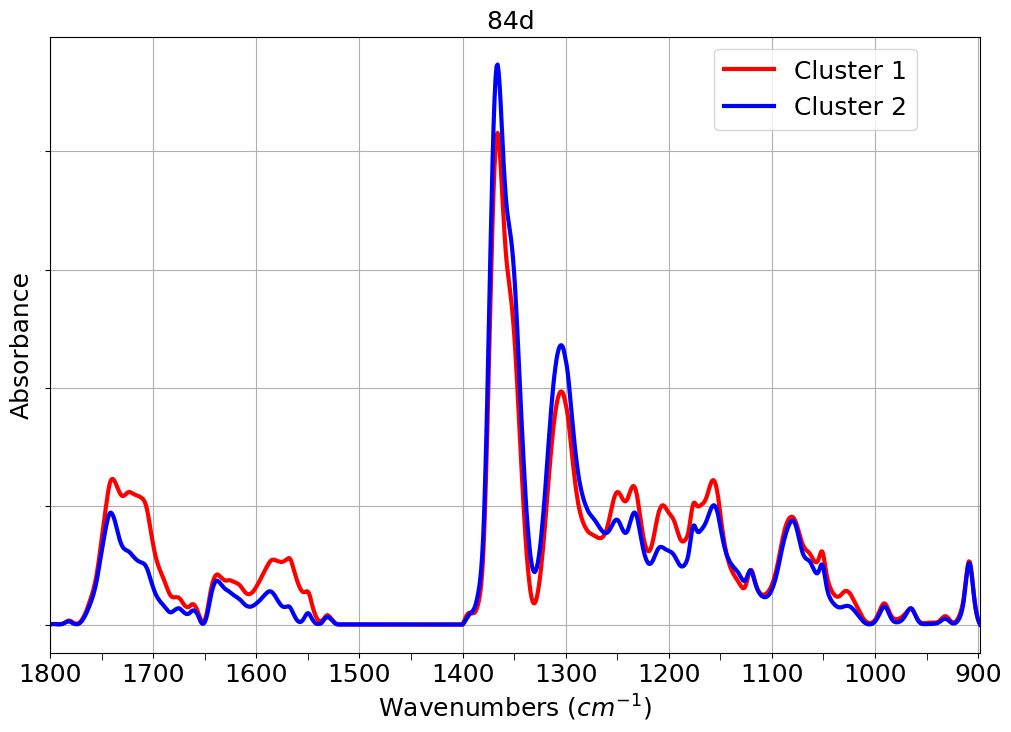

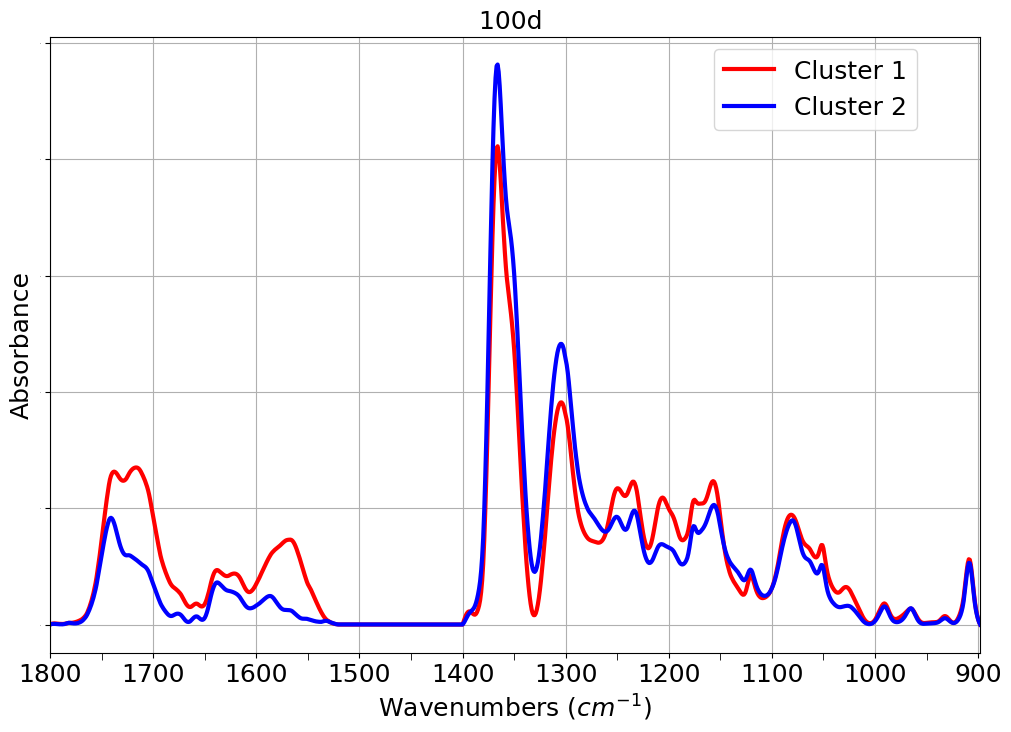

In [ ]:
cluster1_spectra = []
cluster2_spectra = []

plot = False

for key in keys: 
    training_df = dfs[key]

    clustered_df = training_df.groupby('cluster').mean(numeric_only=True)

    clustered_spectra = clustered_df[wavenumbers]
    frequencies = wavenumbers.astype(float)

    cluster1_spectra.append(clustered_spectra.values[0].astype(float))
    cluster2_spectra.append(clustered_spectra.values[1].astype(float))
    if plot == True:
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.set_ylabel('Absorbance', fontsize=18)
        ax.set_xlabel(r'Wavenumbers ($cm^{-1}$)', fontsize=18)
        ax.set_title(key[:-5], fontsize=18)
        ax.plot(frequencies, clustered_spectra.values[0].astype(float), color='r', linewidth=3)
        ax.plot(frequencies, clustered_spectra.values[1].astype(float), color='b', linewidth=3)
        
        ax.tick_params(which='major', axis='x', labelsize=18)
        ax.tick_params(which='minor', axis='x', length=5)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
        ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))
        ax.legend(labels=['Cluster 1', 'Cluster 2'],
                fontsize=18, loc='upper left', 
                bbox_to_anchor=(0.7, 0.5, 0.5, 0.5))
        ax.tick_params(axis='y', labelsize=0)

        ax.set_xlim(frequencies[-1], frequencies[0])
        ax.grid(True)

Plotting the spectra of each Cluster as a Function of Time

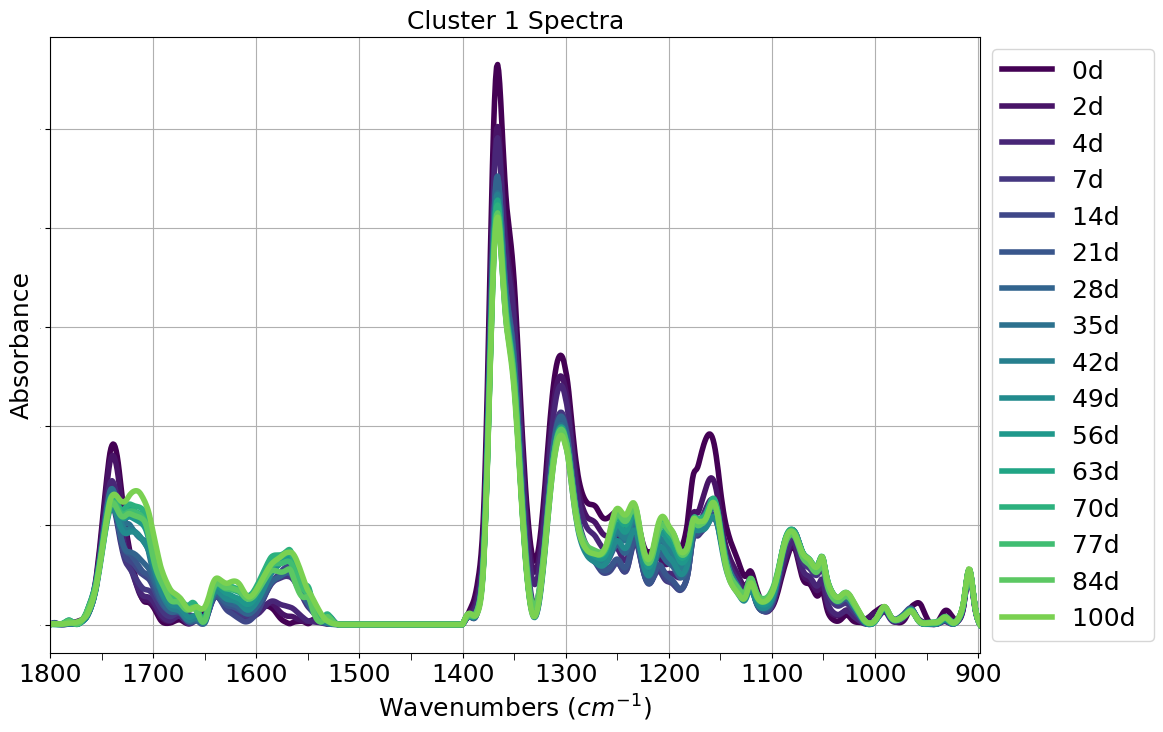

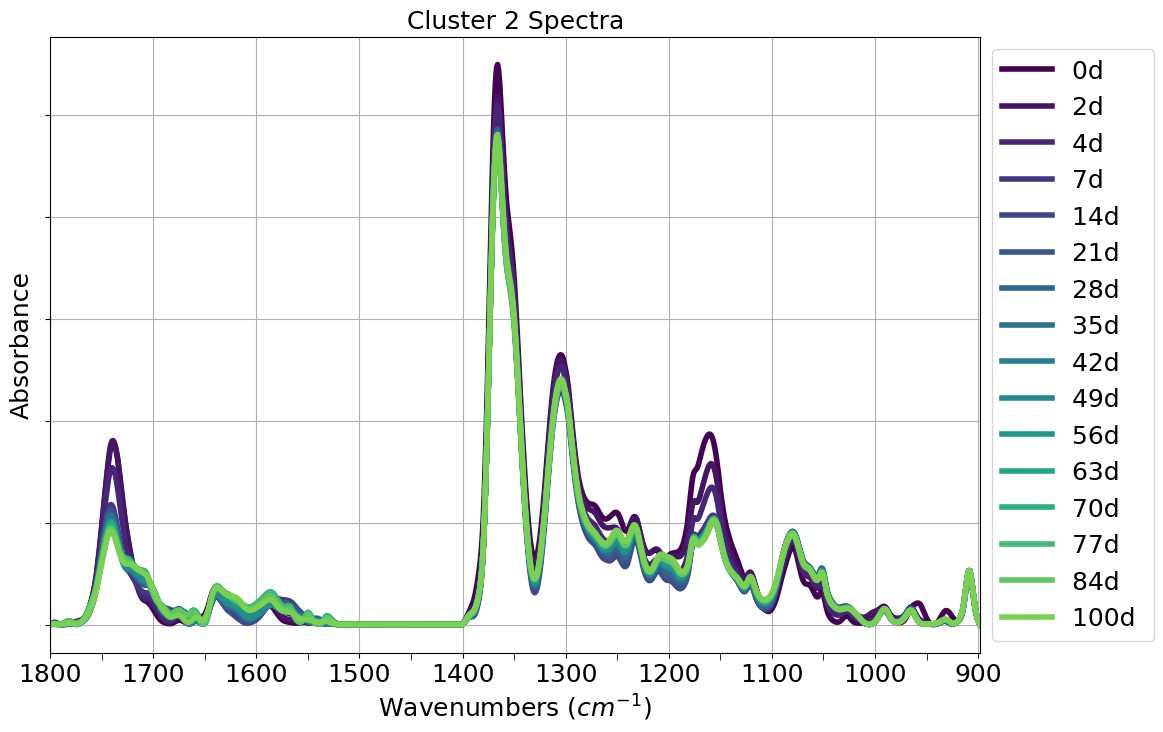

In [13]:
fig, ax = plt.subplots(figsize=(12, 8))

cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 0.8, len(cluster1_spectra)))

ax.set_ylabel('Absorbance', fontsize=18)
ax.set_xlabel(r'Wavenumbers ($cm^{-1}$)', fontsize=18)
ax.set_title("Cluster 1 Spectra", fontsize=18)

for i in range(len(cluster1_spectra)):
        ax.plot(frequencies, cluster1_spectra[i], color=colors[i], linewidth=4)

ax.tick_params(which='major', axis='x', labelsize=18)
ax.tick_params(which='minor', axis='x', length=5)
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))
ax.legend(labels=[key[:-5] for key in keys],
        fontsize=18, loc='upper right', 
        bbox_to_anchor=(0.7, 0.5, 0.5, 0.5))
ax.tick_params(axis='y', labelsize=0)

ax.set_xlim(frequencies[-1], frequencies[0])
ax.grid(True)


fig, ax = plt.subplots(figsize=(12, 8))

cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 0.8, len(cluster2_spectra)))

ax.set_ylabel('Absorbance', fontsize=18)
ax.set_xlabel(r'Wavenumbers ($cm^{-1}$)', fontsize=18)
ax.set_title("Cluster 2 Spectra", fontsize=18)

for i in range(len(cluster2_spectra)):
        ax.plot(frequencies, cluster2_spectra[i], color=colors[i], linewidth=4)

ax.tick_params(which='major', axis='x', labelsize=18)
ax.tick_params(which='minor', axis='x', length=5)
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))
ax.legend(labels=[key[:-5] for key in keys],
        fontsize=18, loc='upper right', 
        bbox_to_anchor=(0.7, 0.5, 0.5, 0.5))
ax.tick_params(axis='y', labelsize=0)

ax.set_xlim(frequencies[-1], frequencies[0])
ax.grid(True)

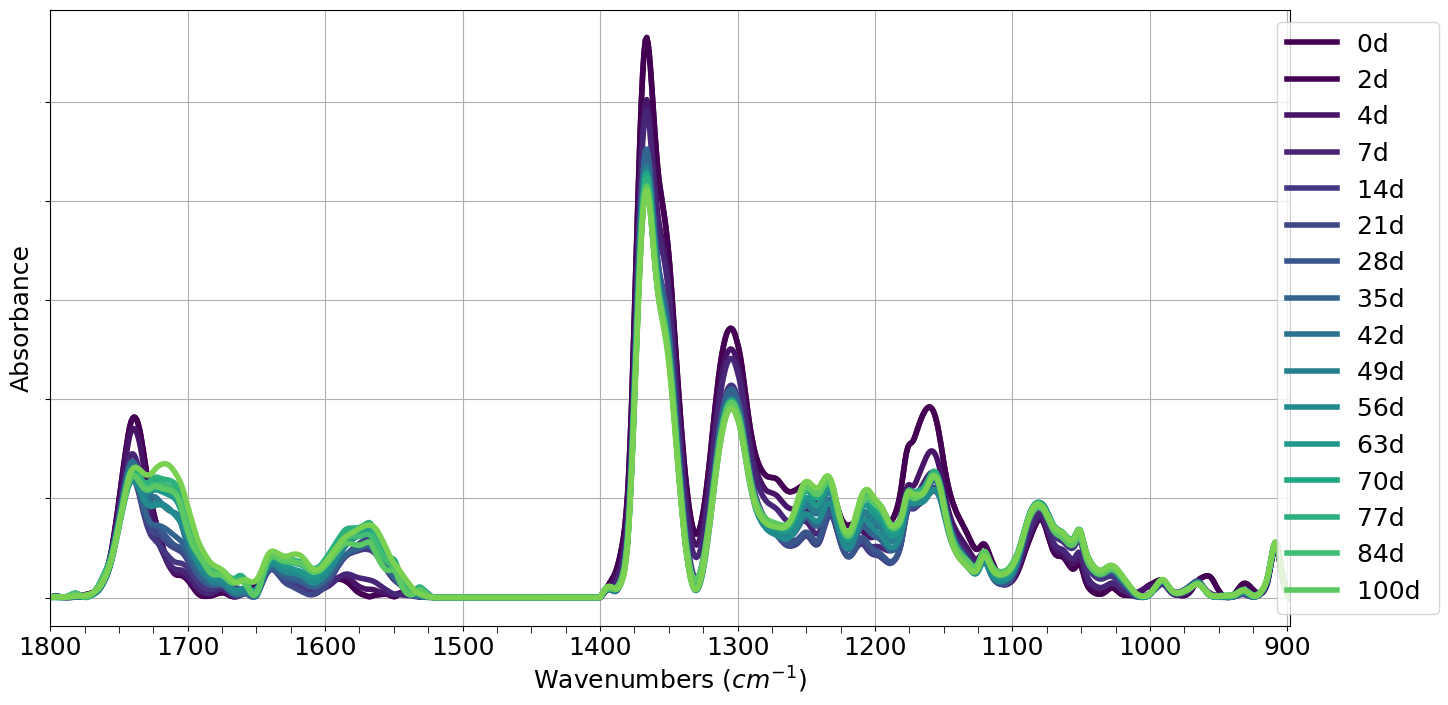

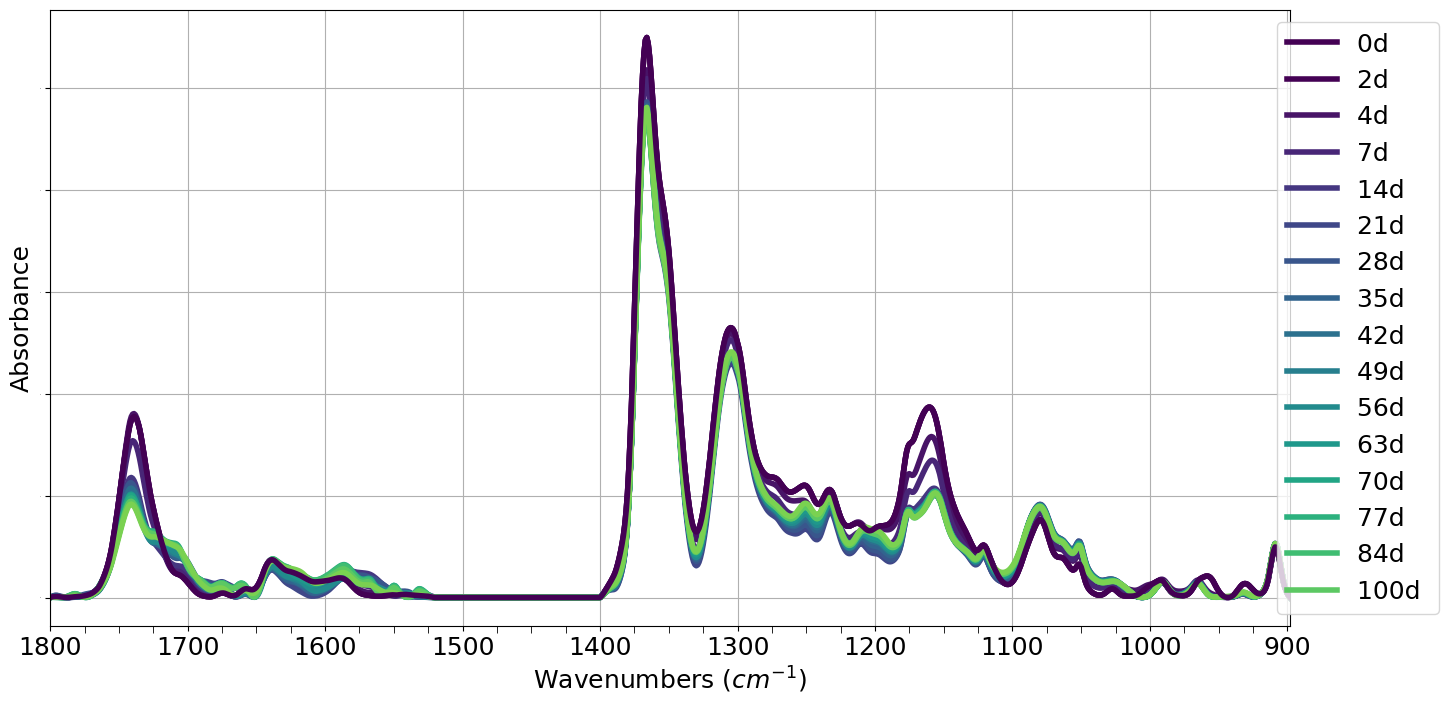

In [14]:
from matplotlib.animation import FuncAnimation
"""
Animation for the Cluster Associated with the Hotspot

"""
fig, ax = plt.subplots(figsize=(16, 8))

cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 0.8, len(cluster1_spectra)))

ax.set_ylabel('Absorbance', fontsize=18)
ax.set_xlabel(r'Wavenumbers ($cm^{-1}$)', fontsize=18)
ax.tick_params(which='major', axis='x', labelsize=18)
ax.tick_params(which='minor', axis='x', length=5)

ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(25))

ax.tick_params(axis='y', labelsize=0)

ax.set_xlim(frequencies[-1], frequencies[0])
ax.grid(True)

def animate(frame):
        line,=ax.plot(frequencies, cluster1_spectra[frame], color=colors[frame], linewidth=4)
        ax.legend(labels=[key[:-5] for key in keys],
        fontsize=18, loc='upper right', 
        bbox_to_anchor=(0.63, 0.5, 0.5, 0.5))
        return line, 

ani = FuncAnimation(fig=fig, func=animate, interval=800, frames=len(cluster1_spectra),  blit=False)
ani.save("./hotspot_spectra.gif", writer="pillow")

"""
Animation for the Cluster Associated with the Bulk

"""
fig, ax = plt.subplots(figsize=(16, 8))

cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 0.8, len(cluster2_spectra)))

ax.set_ylabel('Absorbance', fontsize=18)
ax.set_xlabel(r'Wavenumbers ($cm^{-1}$)', fontsize=18)
ax.tick_params(which='major', axis='x', labelsize=18)
ax.tick_params(which='minor', axis='x', length=5)

ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(25))

ax.tick_params(axis='y', labelsize=0)

ax.set_xlim(frequencies[-1], frequencies[0])
ax.grid(True)

def animate(frame):
        line,=ax.plot(frequencies, cluster2_spectra[frame], color=colors[frame], linewidth=4)
        ax.legend(labels=[key[:-5] for key in keys],
        fontsize=18, loc='upper right', 
        bbox_to_anchor=(0.63, 0.5, 0.5, 0.5))
        return line, 

ani = FuncAnimation(fig=fig, func=animate, interval=800, frames=len(cluster2_spectra),  blit=False)
ani.save("./bulk_spectra.gif", writer="pillow")


Hyperspectra of PCA 

Explained variation per principal component: [0.29776839 0.15356028 0.13142279 0.08348042 0.042826   0.0320888
 0.02921577 0.02624947 0.01823606 0.01520045]
Explained variation per principal component: [0.28360318 0.19617213 0.10560951 0.08588425 0.07730952 0.03484841
 0.02963859 0.01925876 0.01584944 0.01497052]
Explained variation per principal component: [0.30339402 0.16866437 0.11851911 0.08882878 0.07361338 0.03711692
 0.0241311  0.01891235 0.01717878 0.01356516]
Explained variation per principal component: [0.29785817 0.16037586 0.10668984 0.08349238 0.07709974 0.03816888
 0.03304252 0.02304204 0.01739632 0.01355869]
Explained variation per principal component: [0.31175452 0.26449266 0.11317809 0.06216948 0.05081105 0.03078133
 0.02241125 0.0160358  0.01170951 0.01065908]
Explained variation per principal component: [0.33021852 0.17826075 0.12925031 0.06757338 0.04202612 0.03948954
 0.02621322 0.02008442 0.01420772 0.01237532]
Explained variation per principal component: [0.42812

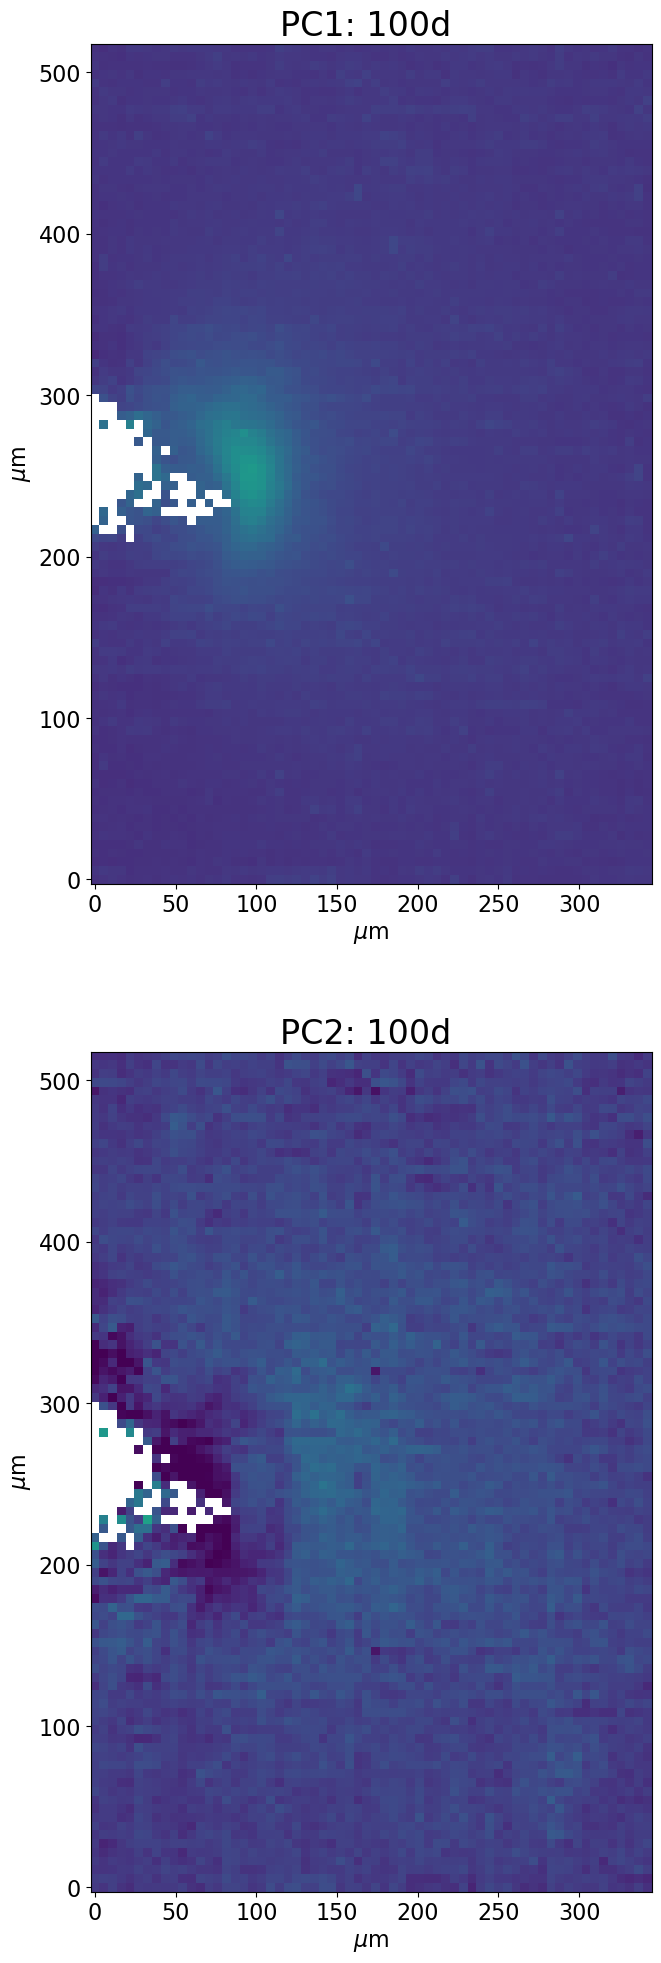

In [15]:
PC1_list = []*len(keys)
PC2_list = []*len(keys)

for i, key in enumerate(keys):
    training_df = dfs[key]
    #Reposition the mapping to start at 0,0 
    Map_x = training_df['map_x'].to_numpy()
    Map_y = training_df['map_y'].to_numpy()
    Map_y2 = []
    Map_x2 = []
    Min_x = min(Map_x)
    Min_y = min(Map_y)

    Map_x2 = Map_x - Min_x
    Map_y2 = Map_y - Min_y

    training_df.loc[:, 'map_x'] = Map_x2
    training_df.loc[:, 'map_y'] = Map_y2

    x_unique = np.sort(training_df["map_x"].unique())
    y_unique = np.sort(training_df["map_y"].unique())

    X, Y = np.meshgrid(x_unique, y_unique)

    PCs=10

    PC_inputData = training_df[wavenumbers].copy()

    PCA_output = IR_PCA(PC_inputData, PCs, normalize=True)

    PC_df = PCA_output[0]
    PC_df['map_x'] = Map_x2
    PC_df['map_y'] = Map_y2
    
    Pivot_PC_df = PC_df.pivot(index="map_y", columns="map_x").sort_index(ascending=True)

    PC1_list.append(Pivot_PC_df['PC1'].values)
    PC2_list.append(Pivot_PC_df['PC2'].values)


fig = plt.figure(figsize=(16, 24))

"""
PC1

"""

cmap1 = plt.get_cmap('viridis')
colors = cmap1(np.linspace(0, 0.8, len(PC1_list)))

ax1 = fig.add_subplot(211)
# Initial frame
mesh1 = ax1.pcolormesh(
    X,
    Y,
    PC1_list[0],
    shading="auto",
    cmap=cmap
)

ax1.tick_params(axis='x', labelsize=16)
ax1.tick_params(axis='y', labelsize=16)

ax1.set_xlabel(f'$\mu$m', fontsize=16)
ax1.set_ylabel(f'$\mu$m', fontsize=16)

"""
PC2

"""

cmap2 = plt.get_cmap('viridis')
colors = cmap2(np.linspace(0, 0.8, len(PC2_list)))

ax2 = fig.add_subplot(212)
# Initial frame
mesh2 = ax2.pcolormesh(
    X,
    Y,
    PC2_list[0],
    shading="auto",
    cmap=cmap
)

ax1.tick_params(axis='x', labelsize=16)
ax1.tick_params(axis='y', labelsize=16)

ax1.set_xlabel(f'$\mu$m', fontsize=16)
ax1.set_ylabel(f'$\mu$m', fontsize=16)

ax1.set_aspect('equal')

ax2.tick_params(axis='x', labelsize=16)
ax2.tick_params(axis='y', labelsize=16)

ax2.set_xlabel(f'$\mu$m', fontsize=16)
ax2.set_ylabel(f'$\mu$m', fontsize=16)

ax2.set_aspect('equal')

# Optional titles for each frame
titles1 = [f"PC1: {key[:-5]}" for key in keys]
titles2 = [f"PC2: {key[:-5]}" for key in keys]

def animate(frame):

    # Update mesh values
    mesh1.set_array(PC1_list[frame].ravel())
    mesh2.set_array(PC2_list[frame].ravel())
    # Update title
    ax1.set_title(titles1[frame], fontsize=24)
    ax2.set_title(titles2[frame], fontsize=24)

    return mesh1, mesh2,

ani = FuncAnimation(
    fig,
    animate,
    frames=len(PC1_list),
    interval=800,   
    blit=False,
    repeat=False
)
ani.save("./PCs_hyperspectra.gif", writer="pillow")
plt.show()

Loading Spectra of Entire Dataset

Explained variation per principal component: [0.56605969 0.2594338 ]
   0         1         2         3         4         5         6         7    \
0 -0.0 -0.000231 -0.000511 -0.000827 -0.001152 -0.001448 -0.001667 -0.001763   
1  0.0 -0.000117 -0.000117  0.000002  0.000241  0.000611  0.001100  0.001607   

        8         9    ...       774       775       776       777       778  \
0 -0.001740 -0.001650  ...  0.000079  0.000133  0.000174  0.000213  0.000236   
1  0.002087  0.002542  ...  0.000029 -0.000186 -0.000409 -0.000648 -0.000826   

        779       780       781       782  783  
0  0.000233  0.000213  0.000169  0.000094 -0.0  
1 -0.000883 -0.000823 -0.000633 -0.000329  0.0  

[2 rows x 784 columns]


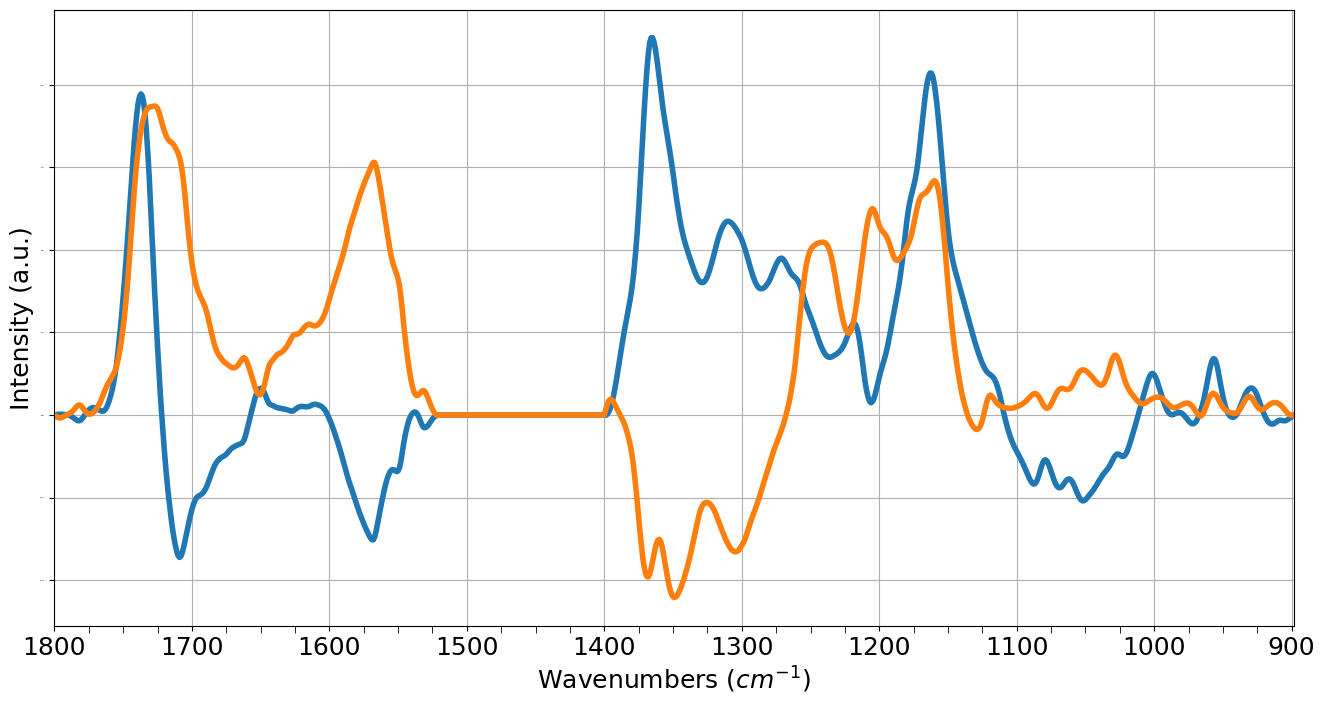

In [16]:
PC_inputData = pd.read_csv("training_data.csv", skiprows=[1,2])

_, _, mask_selected, modePosition, areaPE = distribution_Selection(PC_inputData, '1981.7 - 2095.8', 2)
PC_inputData = PC_inputData[mask_selected].copy()

numlike = compile(r"^-?\d+(\.\d+)?$")

wavenumbers = np.array([c for c in training_df.columns if numlike.match(str(c).strip())])

PC_inputData = PC_inputData[wavenumbers].values

PCs = 2

PCA_output = IR_PCA(PC_inputData, PCs, normalize=False)

PC_df = PCA_output[0]
loadings_df = PCA_output[1]
print(loadings_df)
fig, ax = plt.subplots(figsize=(16, 8))

cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 0.8, len(cluster2_spectra)))
for i in range(len(loadings_df)):
    ax.plot(frequencies, loadings_df.iloc[i], linewidth=4)

ax.set_ylabel('Intensity (a.u.)', fontsize=18)
ax.set_xlabel(r'Wavenumbers ($cm^{-1}$)', fontsize=18)
ax.tick_params(which='major', axis='x', labelsize=18)
ax.tick_params(which='minor', axis='x', length=5)

ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(25))

ax.tick_params(axis='y', labelsize=0)

ax.set_xlim(frequencies[-1], frequencies[0])
ax.grid(True)